<a href="https://colab.research.google.com/github/Michael-M-William/ML-Final-project/blob/michael/Final-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NASA RAW DATA

              
                          │
              
                          ▼
           
                 1. DATA AUDIT
                          │
                          ▼
              2. DATA CLEANING
             - Missing values
             - Invalid values
             - Duplicates
             - IDs / metadata
                          │
                          ▼
              3. DEFINE TARGET
                  pha: N / Y
                          │
                          ▼
             4. TRAIN / VAL / TEST
              70%       15%       15%
               │          │         │
               ▼          ▼         ▼
             TRAIN      VALID      TEST
               │          │         │
               └──────────┴─────────┘
                    NO INFORMATION
                    LEAKAGE BETWEEN
                    SPLITS
                          │
                          ▼
             5. FEATURE ENGINEERING
             Create meaningful orbital
             / physical features
                          │
                          ▼
             6. FEATURE SELECTION
             Select useful features
                          │
                          ▼
             7. PREPROCESSING
             Imputation / Scaling
                          │
                          ▼
             8. PCA EXPERIMENT
             Optional dimensionality
             reduction
                          │
                          ▼
             9. IMBALANCE HANDLING
             ┌────────────┬─────────────┐
             │            │             │
           SMOTE     Class Weight   UnderSampling
             │            │             │
             └────────────┴─────────────┘
                          │
                          ▼
             10. MODEL TRAINING
             LR / SVM / RF / GB /
             XGBoost / etc.
                          │
                          ▼
             11. VALIDATION
             Compare models
                          │
                          ▼
             12. THRESHOLD TUNING
             0.30 / 0.40 / 0.50 / ...
                          │
                          ▼
             13. FINAL MODEL
                          │
                          ▼
             14. TEST ONCE
             Final untouched test set
                          │
                          ▼
             15. FINAL EVALUATION
             Recall / Precision / F1
             ROC-AUC / PR-AUC
             Confusion Matrix




Train

نقدر نعمل عليه:

Imputation
Scaling
Feature Selection
PCA
SMOTE
Class Weight
Undersampling
Model Training


Validation

نستخدمه في:

Model comparison
Threshold tuning
Hyperparameter decisions

لكن لا نعمل عليه SMOTE.

Test

يُترك untouched تمامًا لحد آخر خطوة.

المتغيرات

TARGET

numeric_cols

categorical_cols


# inport lips and data

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [126]:
df=pd.read_csv('https://gitlab.com/mirsakhawathossain/pha-ml/-/raw/master/Dataset/dataset.csv')
display(df.head(2))

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,albedo,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.4,939.4,0.090,0.2,JPL 47,2458600.5,58600,20190427.0,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.2,545.0,0.101,18.0,JPL 37,2459000.5,59000,20200531.0,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936


In [127]:
ID_COLUMNS = [
    "id",
    "spkid",
    "pdes",
    "name",
    "full_name",
    "orbit_id",
    "epoch_cal",
    "prefix"]
existing_id_columns = [
    col for col in ID_COLUMNS
    if col in df.columns]

df = df.drop( columns=existing_id_columns)
print(df.shape)

(958524, 37)


# EDA


---



1.   numirical view



In [128]:
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
print(df.shape)
display(df.head())


(958524, 37)


,neo,pha,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,N,N,3.40,939.400,0.0900,0.200,2458600.5,58600,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,N,N,4.20,545.000,0.1010,18.000,2459000.5,59000,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,N,N,5.33,246.596,0.2140,10.594,2459000.5,59000,J2000,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,2.018112e+07,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,N,N,3.00,525.400,0.4228,0.200,2458600.5,58600,J2000,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,2.018051e+07,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,N,N,6.90,106.699,0.2740,3.140,2459000.5,59000,J2000,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,2.020032e+07,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [129]:
# Target
TARGET = "pha"

# Numerical columns
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

categorical_cols = [col for col in categorical_cols if col != TARGET]

print("Numerical columns:")
print(numeric_cols)
print("\nNumber of numerical columns:", len(numeric_cols))

print("\nCategorical columns:")
print(categorical_cols)
print("\nNumber of categorical columns:", len(categorical_cols))

Numerical columns:
['H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']

Number of numerical columns: 33

Categorical columns:
['neo', 'equinox', 'class']

Number of categorical columns: 3


In [130]:
audit = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=True)
})

audit = audit.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(audit)

audit.to_csv(
    "data_quality_report.csv",
    index=True
)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
albedo,float64,823421,85.91,1057
diameter_sigma,float64,822443,85.80,3054
diameter,float64,822315,85.79,16591
sigma_ma,float64,19922,2.08,266816
pha,object,19921,2.08,2
sigma_w,float64,19922,2.08,262719
sigma_q,float64,19922,2.08,248138
sigma_om,float64,19922,2.08,223155
sigma_i,float64,19922,2.08,215741
sigma_n,float64,19922,2.08,251750


In [131]:

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

print("done")

done


In [132]:

duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate rows     : {duplicate_count:,}")
print(f"Duplicate %        : {duplicate_percentage:.4f}%")
print(f"Unique rows        : {df.drop_duplicates().shape[0]:,}")

Duplicate rows     : 0
Duplicate %        : 0.0000%
Unique rows        : 958,524


In [133]:
target_counts = df[TARGET].value_counts()

if len(target_counts) == 2:
    majority = target_counts.max()
    minority = target_counts.min()

    imbalance_ratio = majority / minority

    print(f"Majority class : {majority:,}")
    print(f"Minority class : {minority:,}")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Majority class : 936,537
Minority class : 2,066
Imbalance ratio: 453.31:1


In [134]:
print(" OUTLIERS")
outlier_results = []
for col in numeric_cols:
    series = df[col].dropna()
    if len(series) == 0:
        continue
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    count = outliers.sum()

    outlier_results.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": count,
        "Outlier %": count / len(df) * 100
    })

outlier_report = pd.DataFrame(outlier_results)

outlier_report = outlier_report.sort_values(
    "Outlier %",
    ascending=False
)

display(outlier_report)

 OUTLIERS


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
21,sigma_e,5.474900e-08,2.336475e-07,1.788985e-07,-2.135988e-07,5.019953e-07,200126,20.878559
23,sigma_q,1.462000e-07,6.583200e-07,5.121200e-07,-6.219800e-07,1.426500e-06,197162,20.569334
29,sigma_n,2.768800e-09,1.124000e-08,8.471200e-09,-9.938000e-09,2.394680e-08,191491,19.977695
28,sigma_ad,2.340900e-08,1.196600e-07,9.625100e-08,-1.209675e-07,2.640365e-07,189300,19.749114
27,sigma_ma,2.573700e-05,1.718900e-04,1.461530e-04,-1.934925e-04,3.911195e-04,189060,19.724076
22,sigma_a,2.046500e-08,1.044675e-07,8.400250e-08,-1.055387e-07,2.304712e-07,188585,19.674520
31,sigma_per,1.794500e-05,9.775475e-05,7.980975e-05,-1.017696e-04,2.174694e-04,188230,19.637484
30,sigma_tp,1.110900e-04,8.139600e-04,7.028700e-04,-9.432150e-04,1.868265e-03,186575,19.464823
26,sigma_w,5.755000e-05,3.114400e-04,2.538900e-04,-3.232850e-04,6.922750e-04,180158,18.795356
24,sigma_i,6.095900e-06,1.591500e-05,9.819100e-06,-8.632750e-06,3.064365e-05,164765,17.189450


2.   graphs



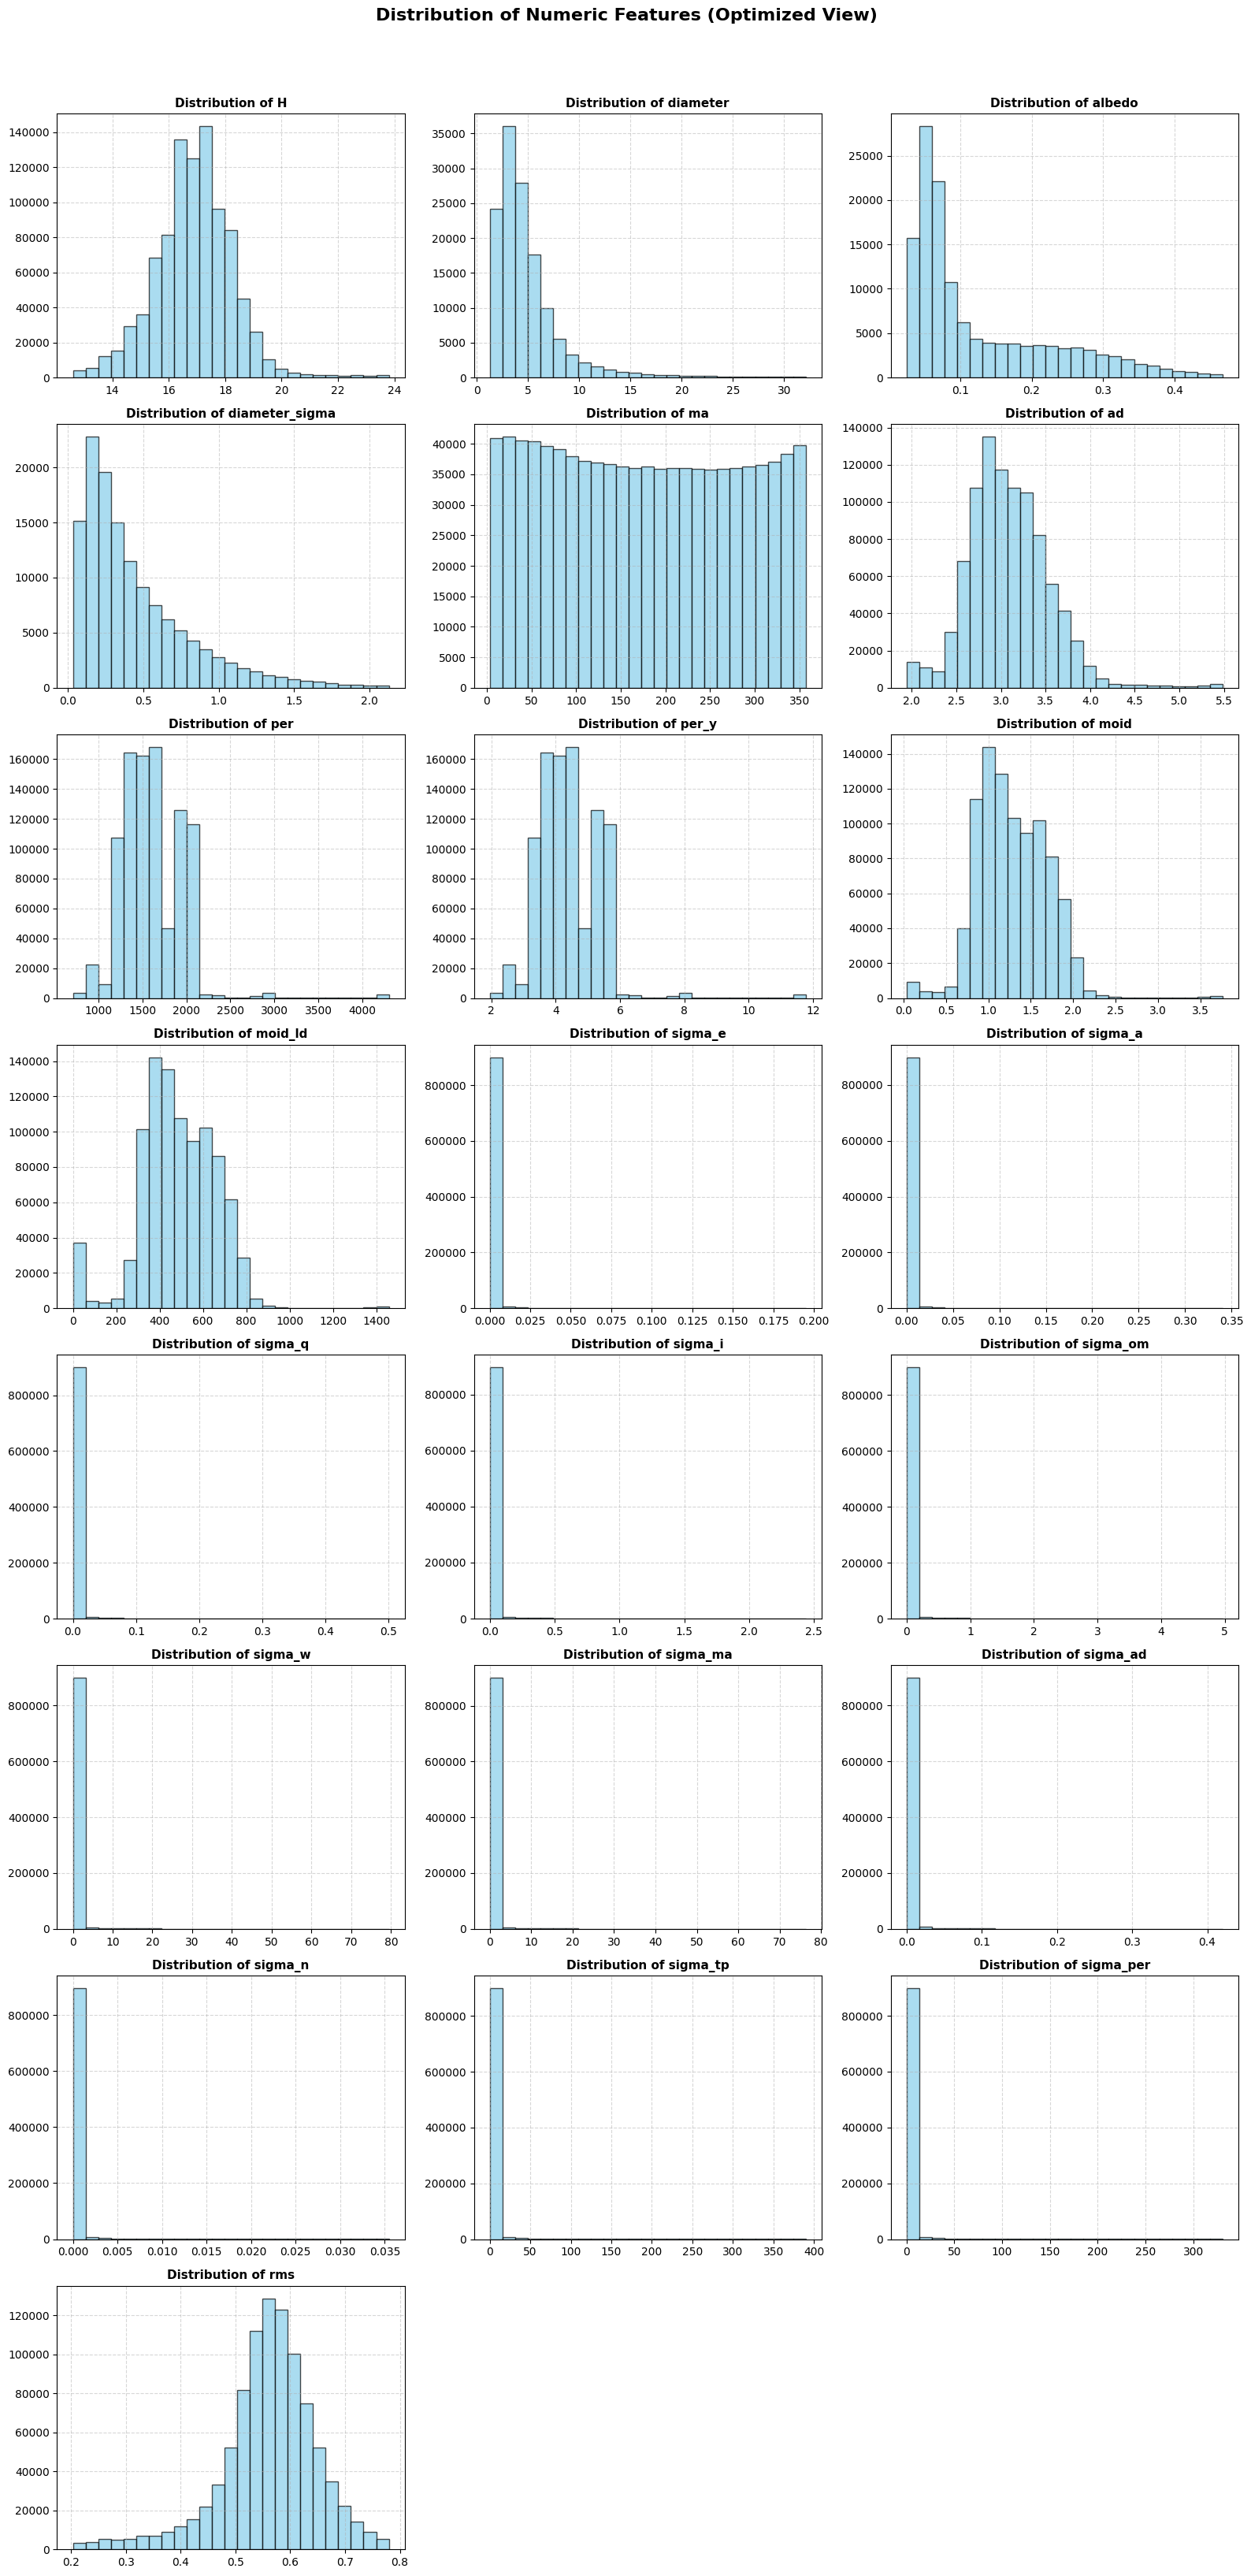

In [135]:
import math
import matplotlib.pyplot as plt

# تحديد الأعمدة الرقمية التي تحتوي على قيم مفقودة
missing_numeric_cols = [col for col in numeric_cols if df[col].isnull().any()]

if missing_numeric_cols:
    num_plots = len(missing_numeric_cols)
    num_cols_per_row = 3  # عرض 3 رسومات في كل صف
    num_rows = math.ceil(num_plots / num_cols_per_row)

    fig_height = max(5, num_rows * 4)
    fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(16, fig_height))
    axes = axes.flatten()

    for i, col in enumerate(missing_numeric_cols):
        series = df[col].dropna()

        # استبعاد القيم المتطرفة الشديدة مؤقتاً للرسم فقط (بين النسبة 1% و 99%)
        q_low = series.quantile(0.01)
        q_high = series.quantile(0.99)
        filtered_series = series[(series >= q_low) & (series <= q_high)]

        # رسم الـ Histogram مع ألوان وتنسيق أفضل
        axes[i].hist(filtered_series, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    # إخفاء أي محاور فارغة فائضة
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Distribution of Numeric Features (Optimized View)", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns with missing values found to plot.")

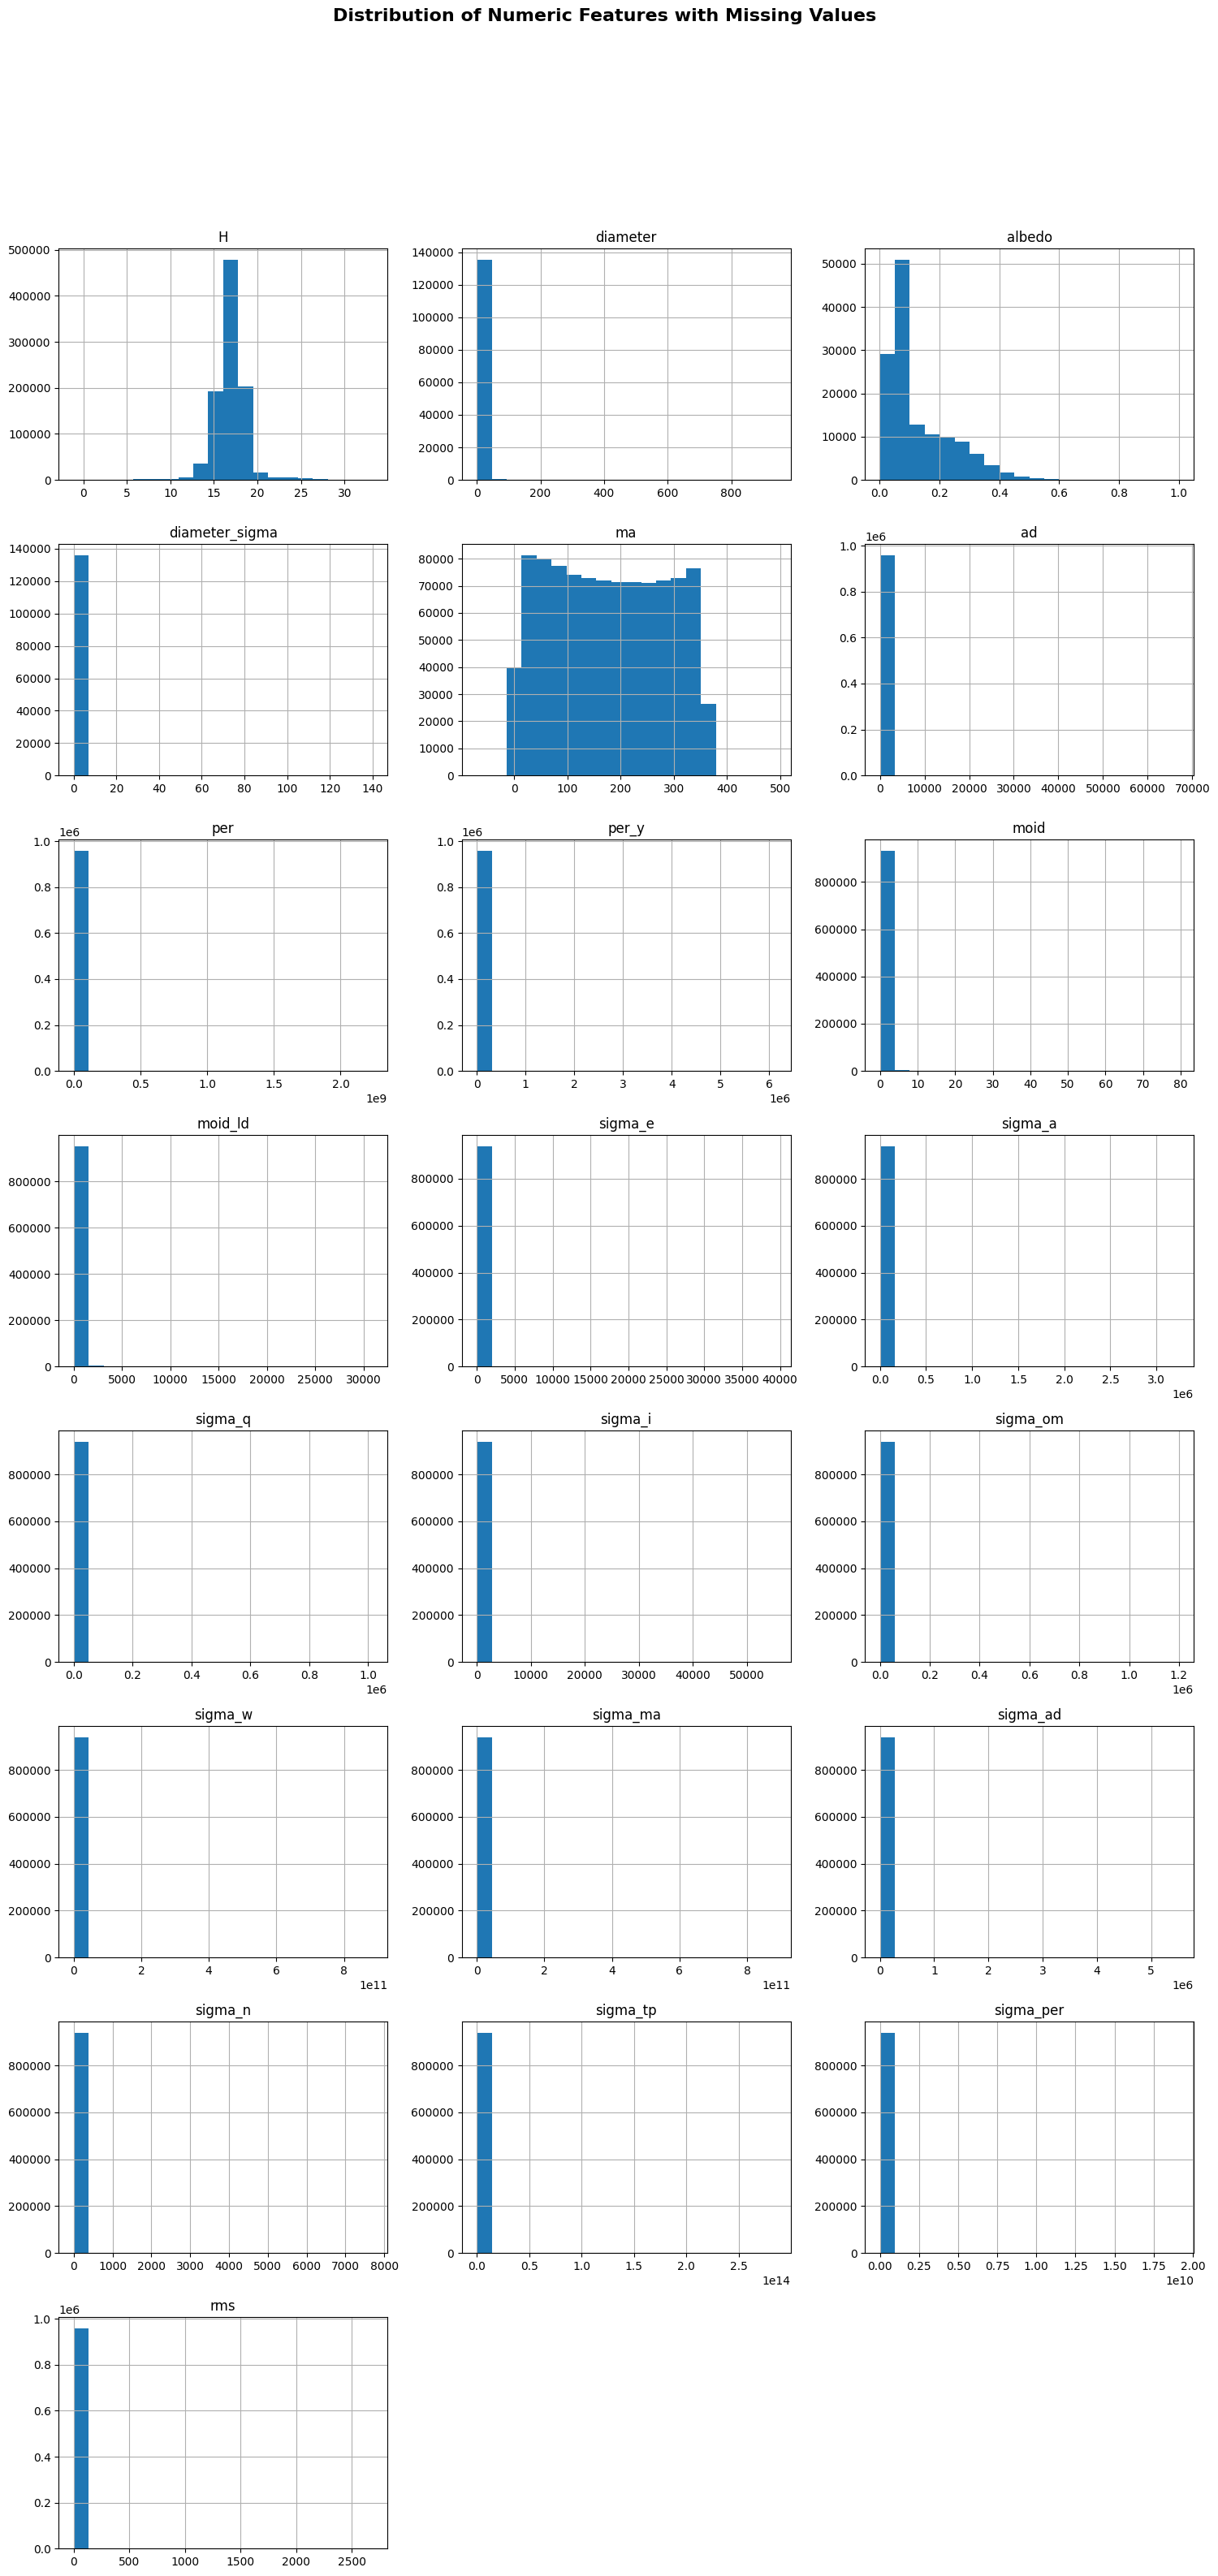

In [136]:
import math

# Identify numeric columns with missing values
missing_numeric_cols = [col for col in numeric_cols if df[col].isnull().any()]

if missing_numeric_cols:
    num_plots = len(missing_numeric_cols)
    num_cols_per_row = 3  # Display up to 3 plots per row
    num_rows = math.ceil(num_plots / num_cols_per_row)

    fig_height = max(5, num_rows * 4) # Adjust height based on number of rows, with a minimum height

    # Plot histograms for numeric columns with missing values
    df[missing_numeric_cols].hist(bins=20, figsize=(15, fig_height), layout=(num_rows, num_cols_per_row))
    plt.suptitle("Distribution of Numeric Features with Missing Values", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle from overlapping
    plt.show()
else:
    print("No numeric columns with missing values found to plot.")

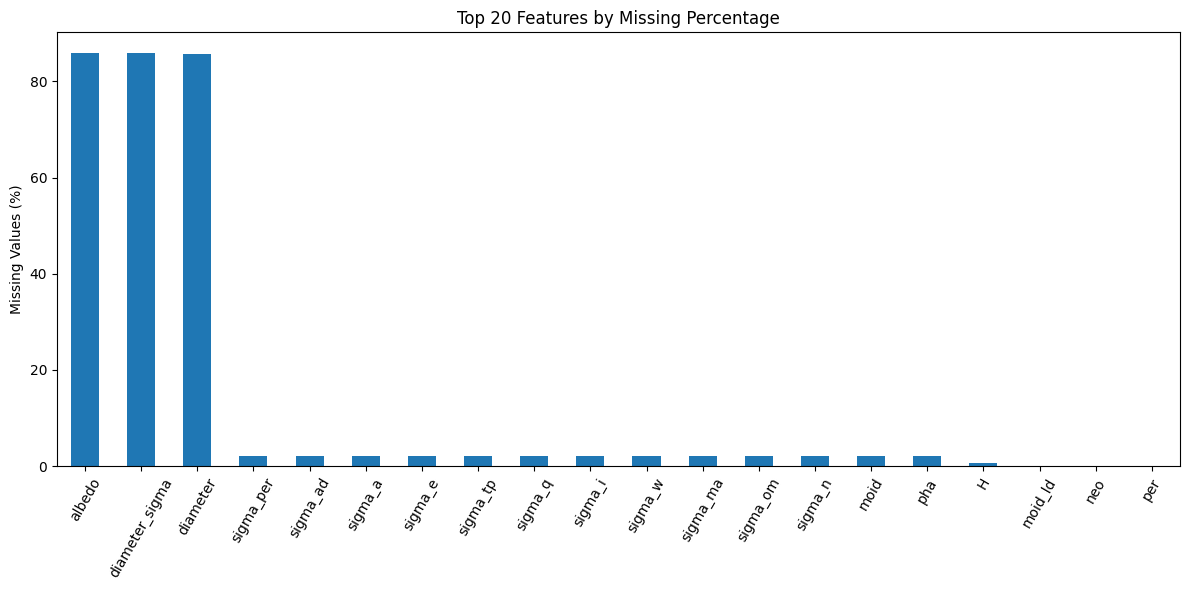

In [137]:
missing_pct = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct = missing_pct[
    missing_pct > 0
]

plt.figure(figsize=(12, 6))

missing_pct.head(20).plot(kind="bar")

plt.title("Top 20 Features by Missing Percentage")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

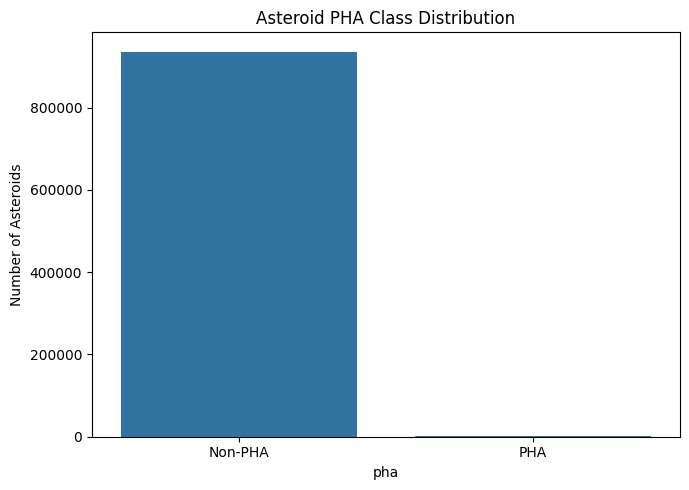

In [138]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

# Map 'N' to 'Non-PHA' and 'Y' to 'PHA'
labels = ["Non-PHA" if x == 'N' else "PHA" for x in target_counts.index]
plt.xticks(ticks=range(len(target_counts.index)), labels=labels)
plt.title("Asteroid PHA Class Distribution")
plt.ylabel("Number of Asteroids")

plt.tight_layout()
plt.show()

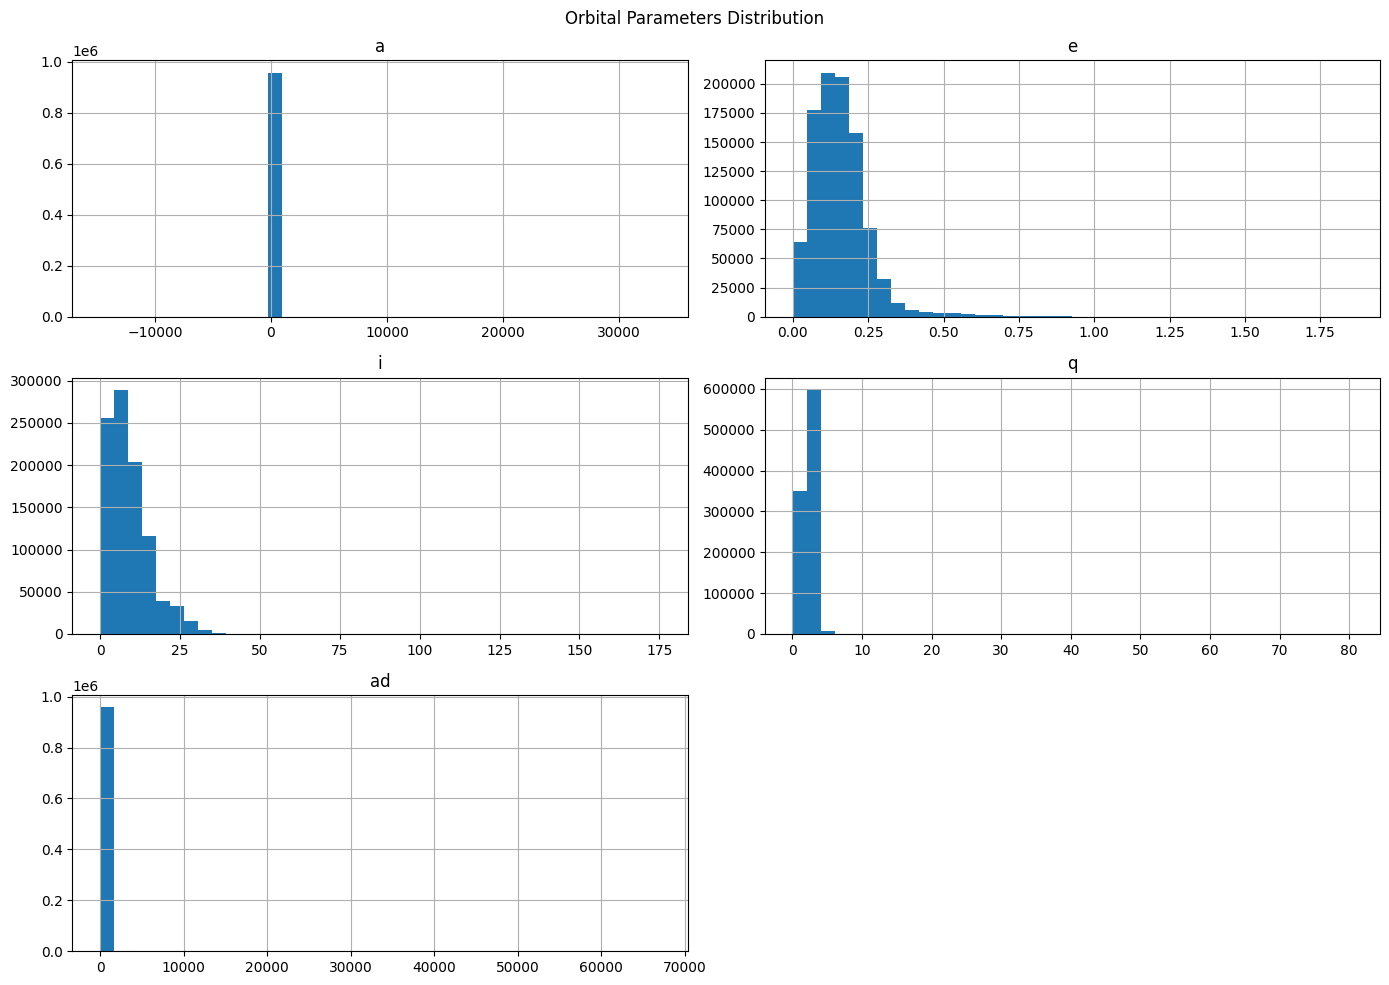

In [139]:
orbital_features = [
    "a", "e", "i", "q", "ad"
]

df[orbital_features].hist(
    figsize=(14, 10),
    bins=40
)

plt.suptitle("Orbital Parameters Distribution")

plt.tight_layout()
plt.show()

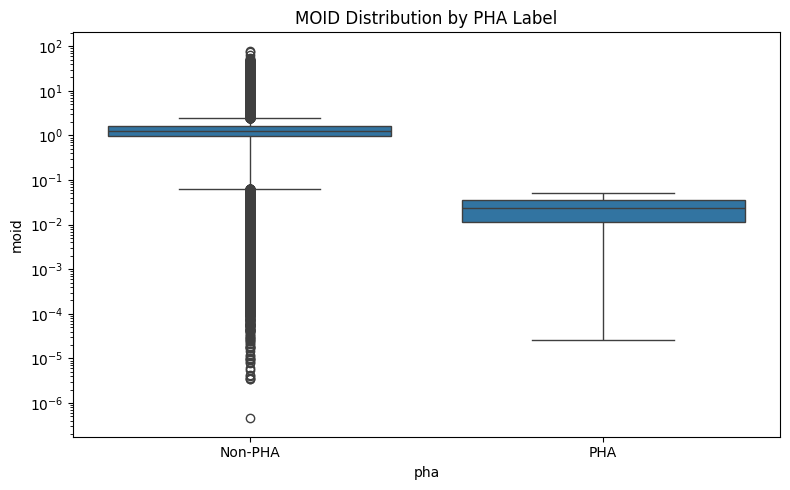

In [140]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pha",
    y="moid"
)

plt.yscale("log")

plt.title("MOID Distribution by PHA Label")
plt.xticks([0, 1], ["Non-PHA", "PHA"])

plt.tight_layout()
plt.show()

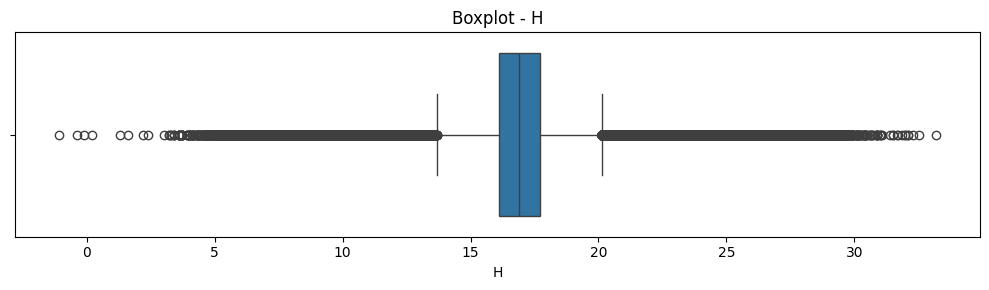

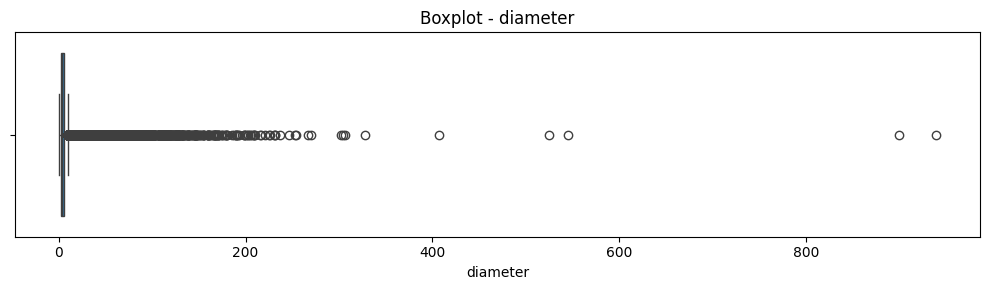

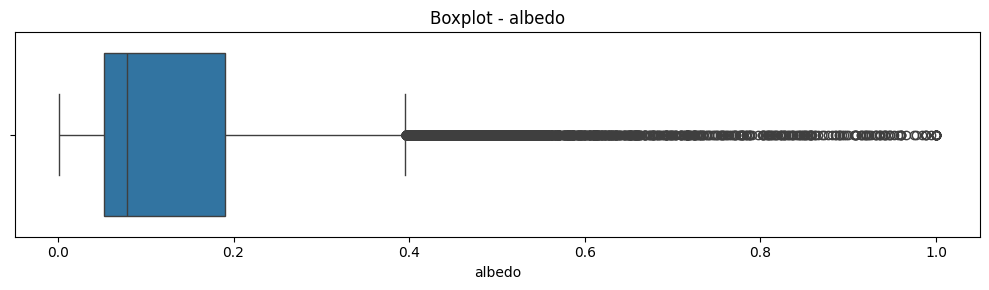

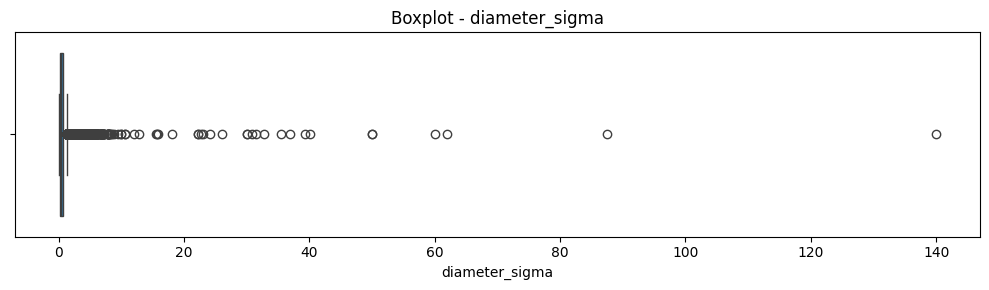

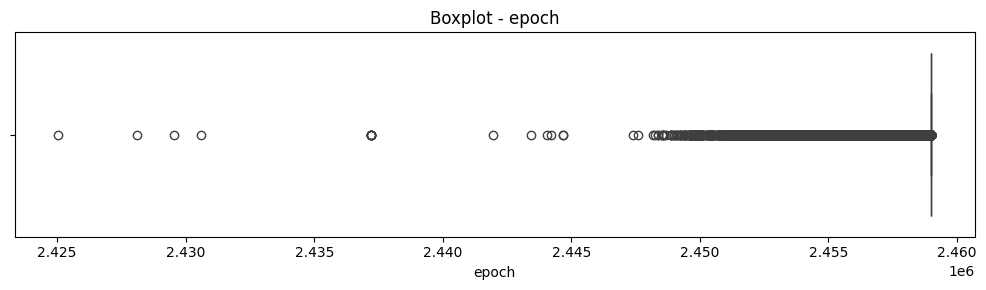

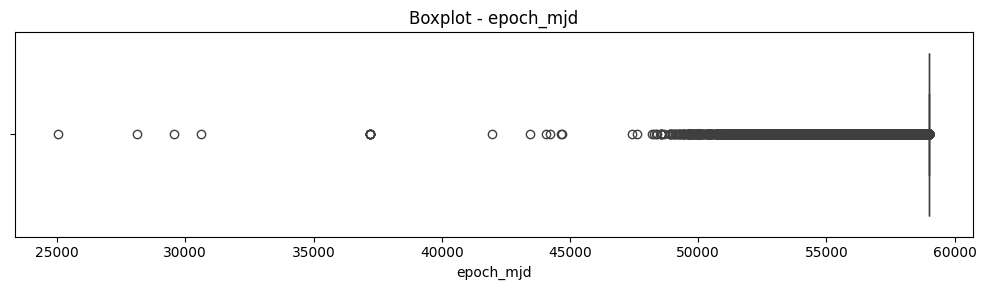

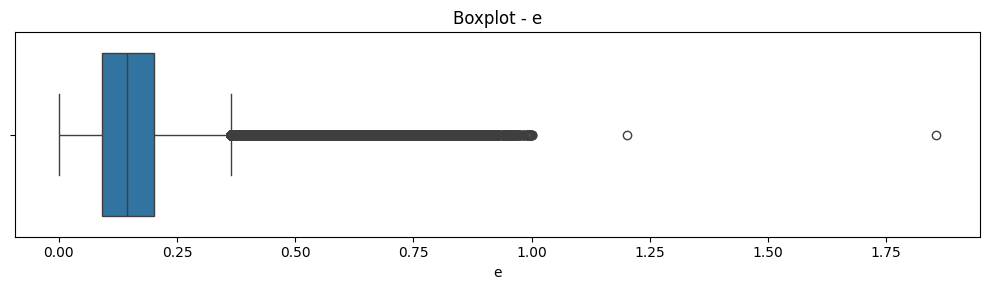

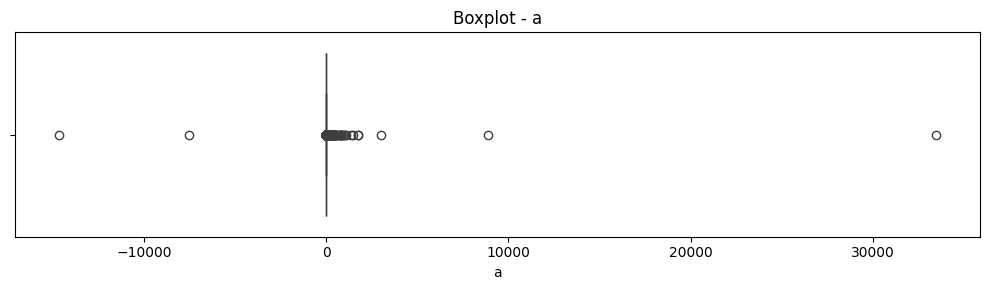

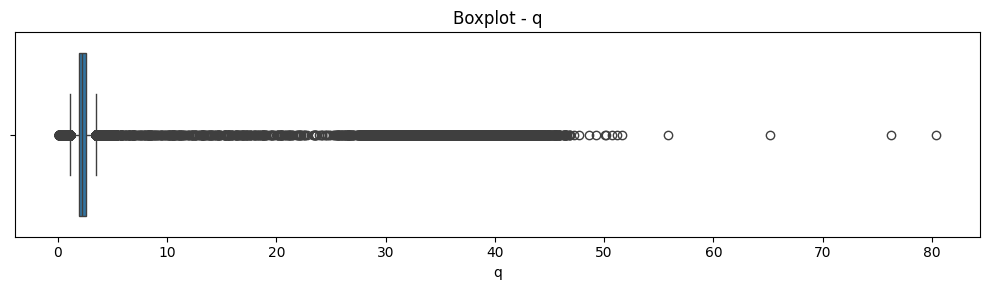

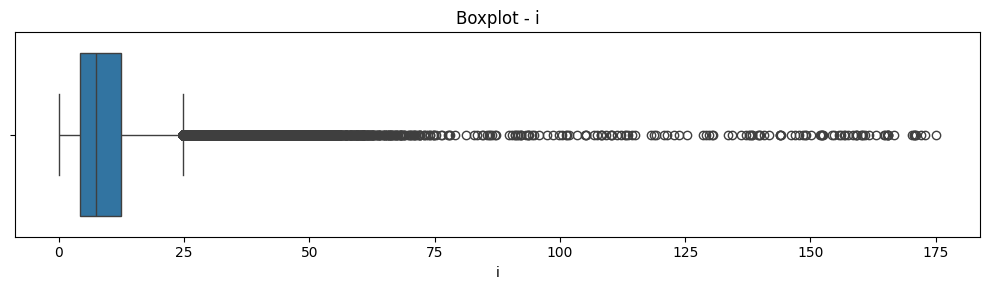

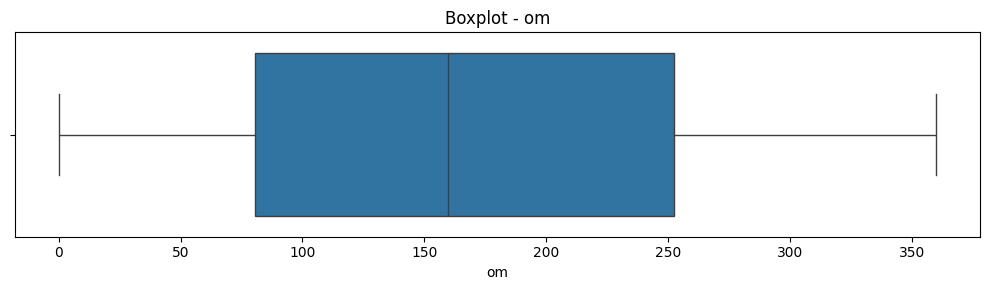

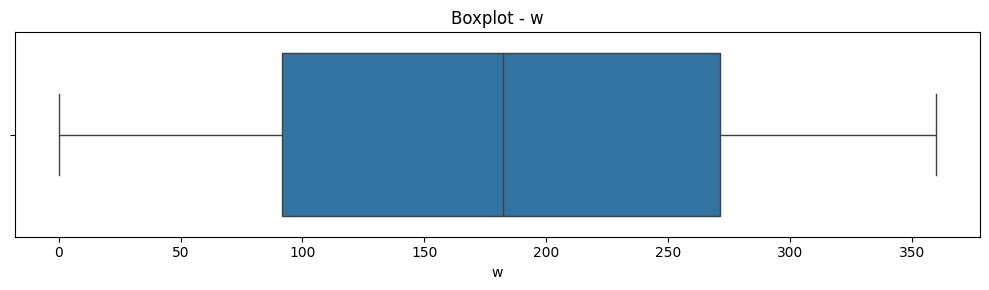

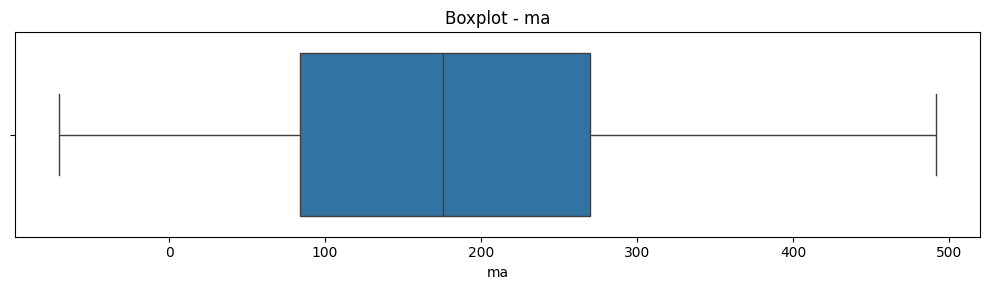

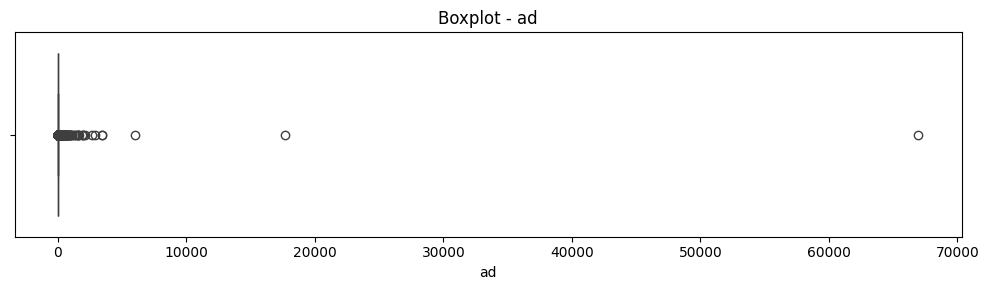

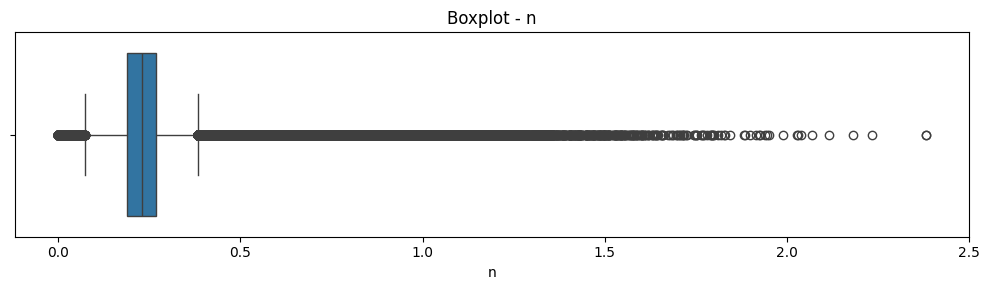

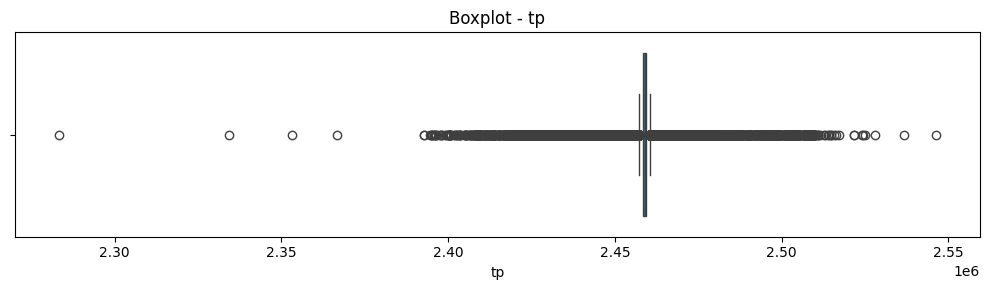

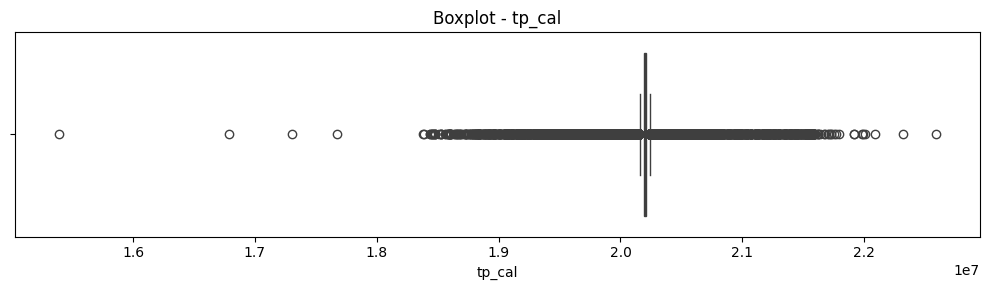

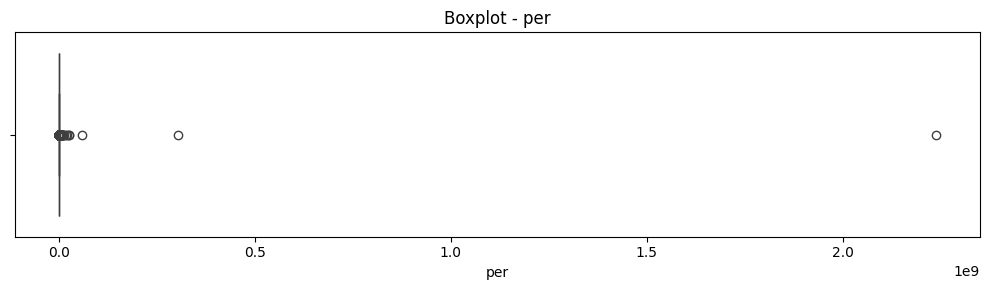

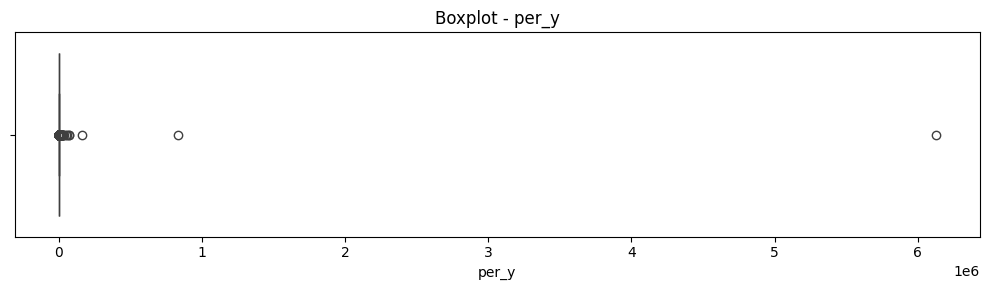

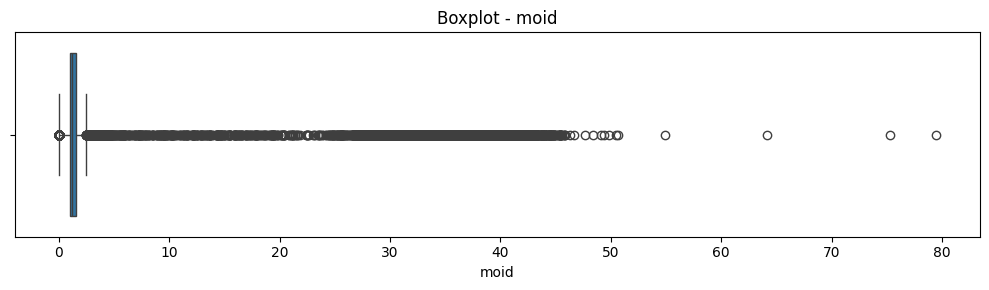

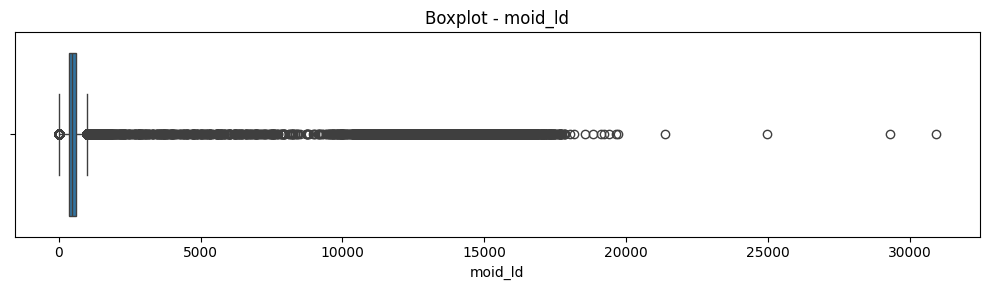

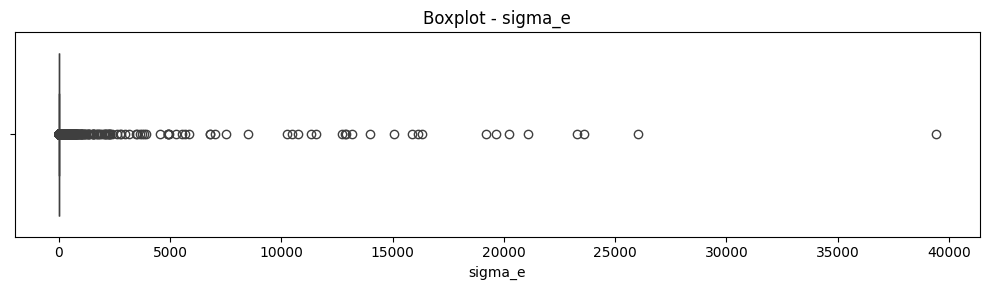

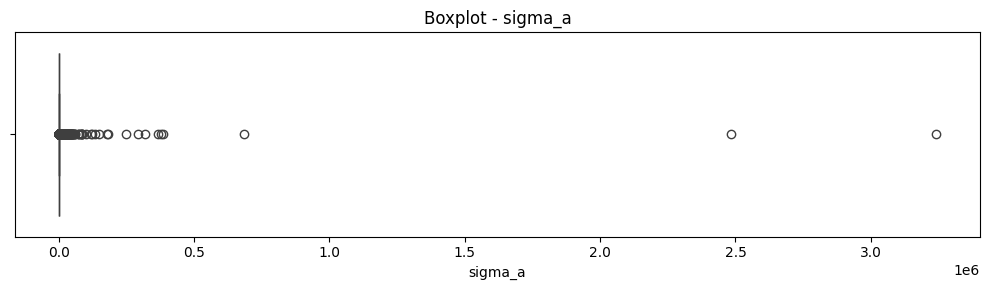

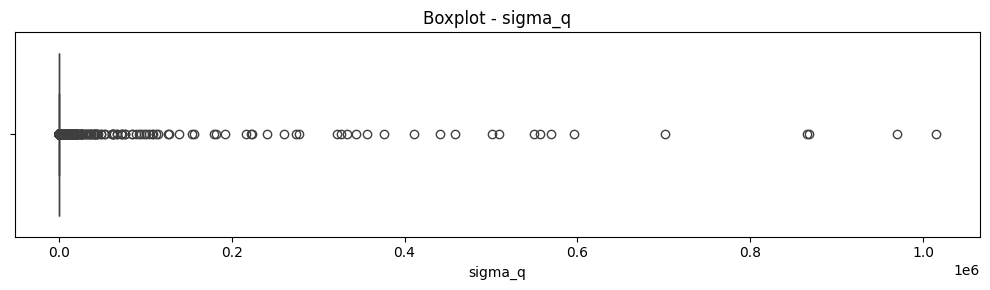

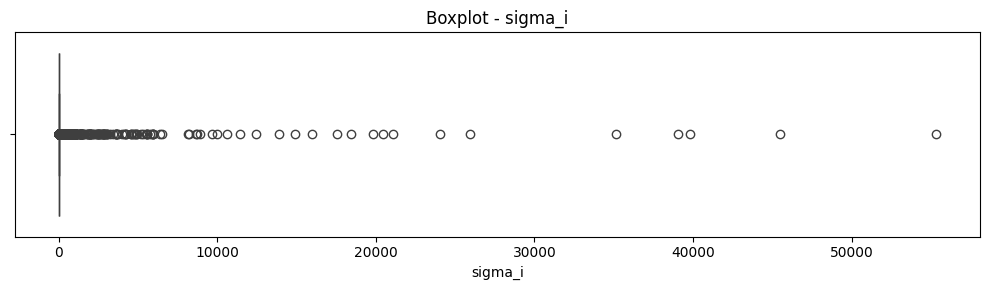

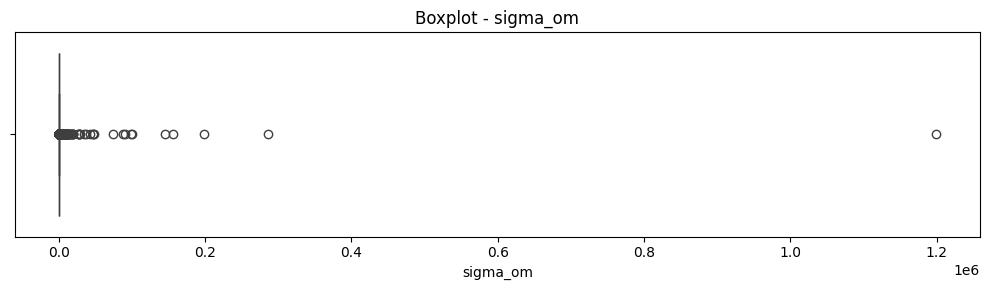

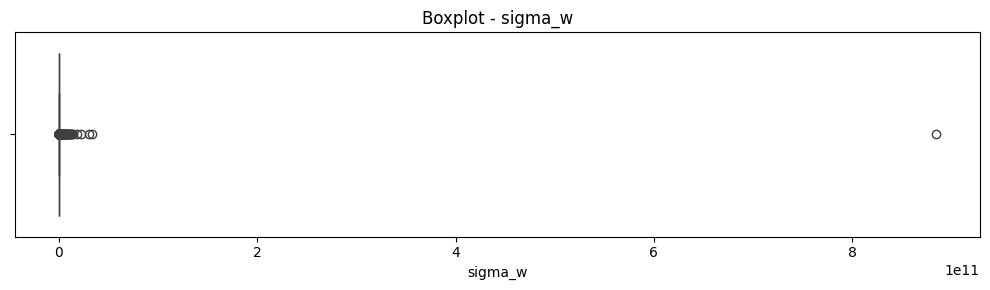

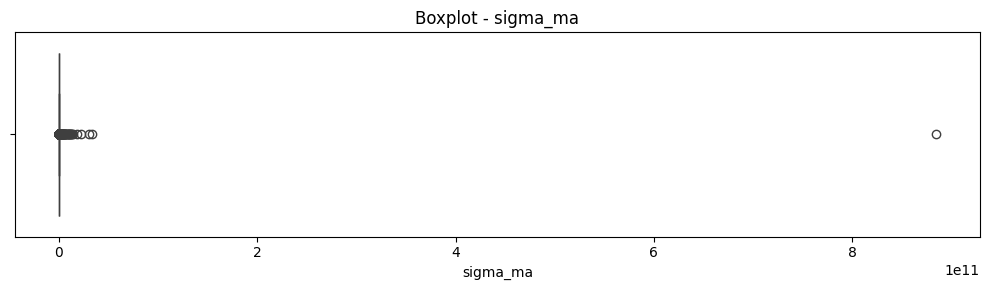

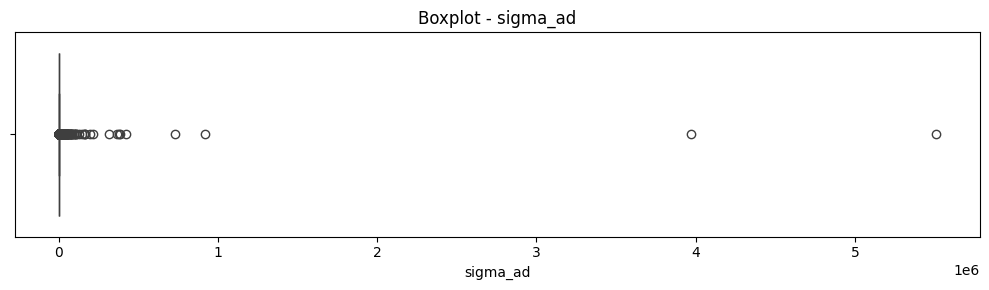

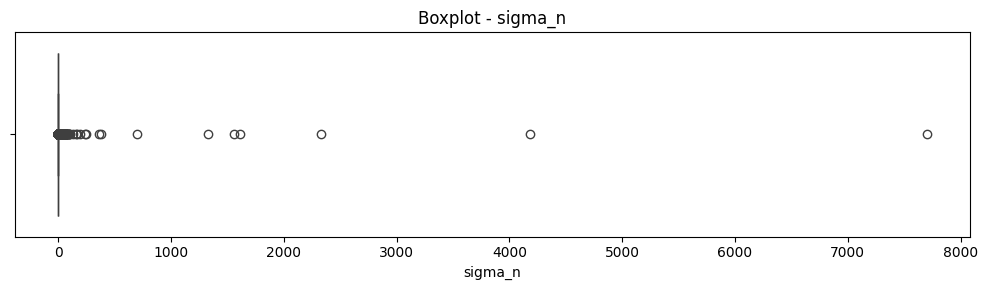

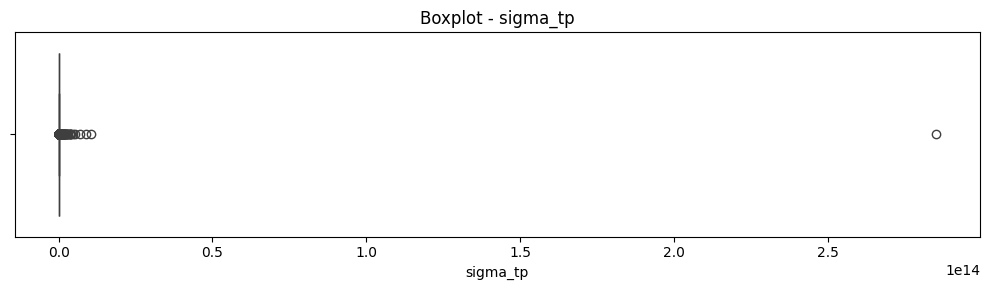

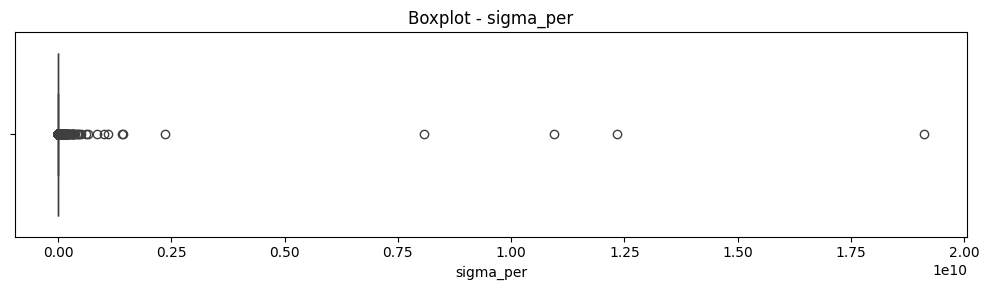

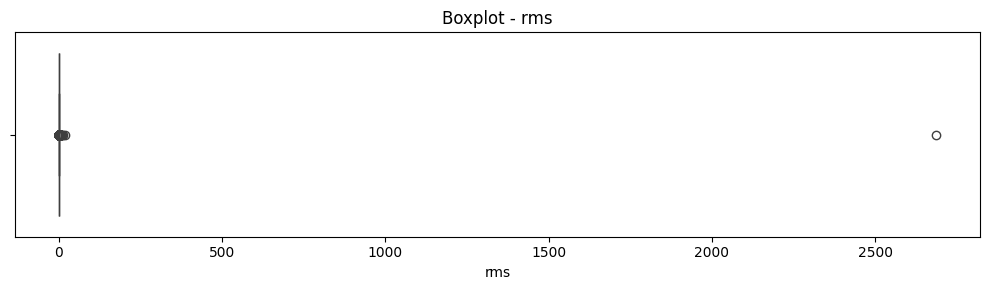

In [141]:
for col in numeric_cols:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.show()

CORRELATIONS


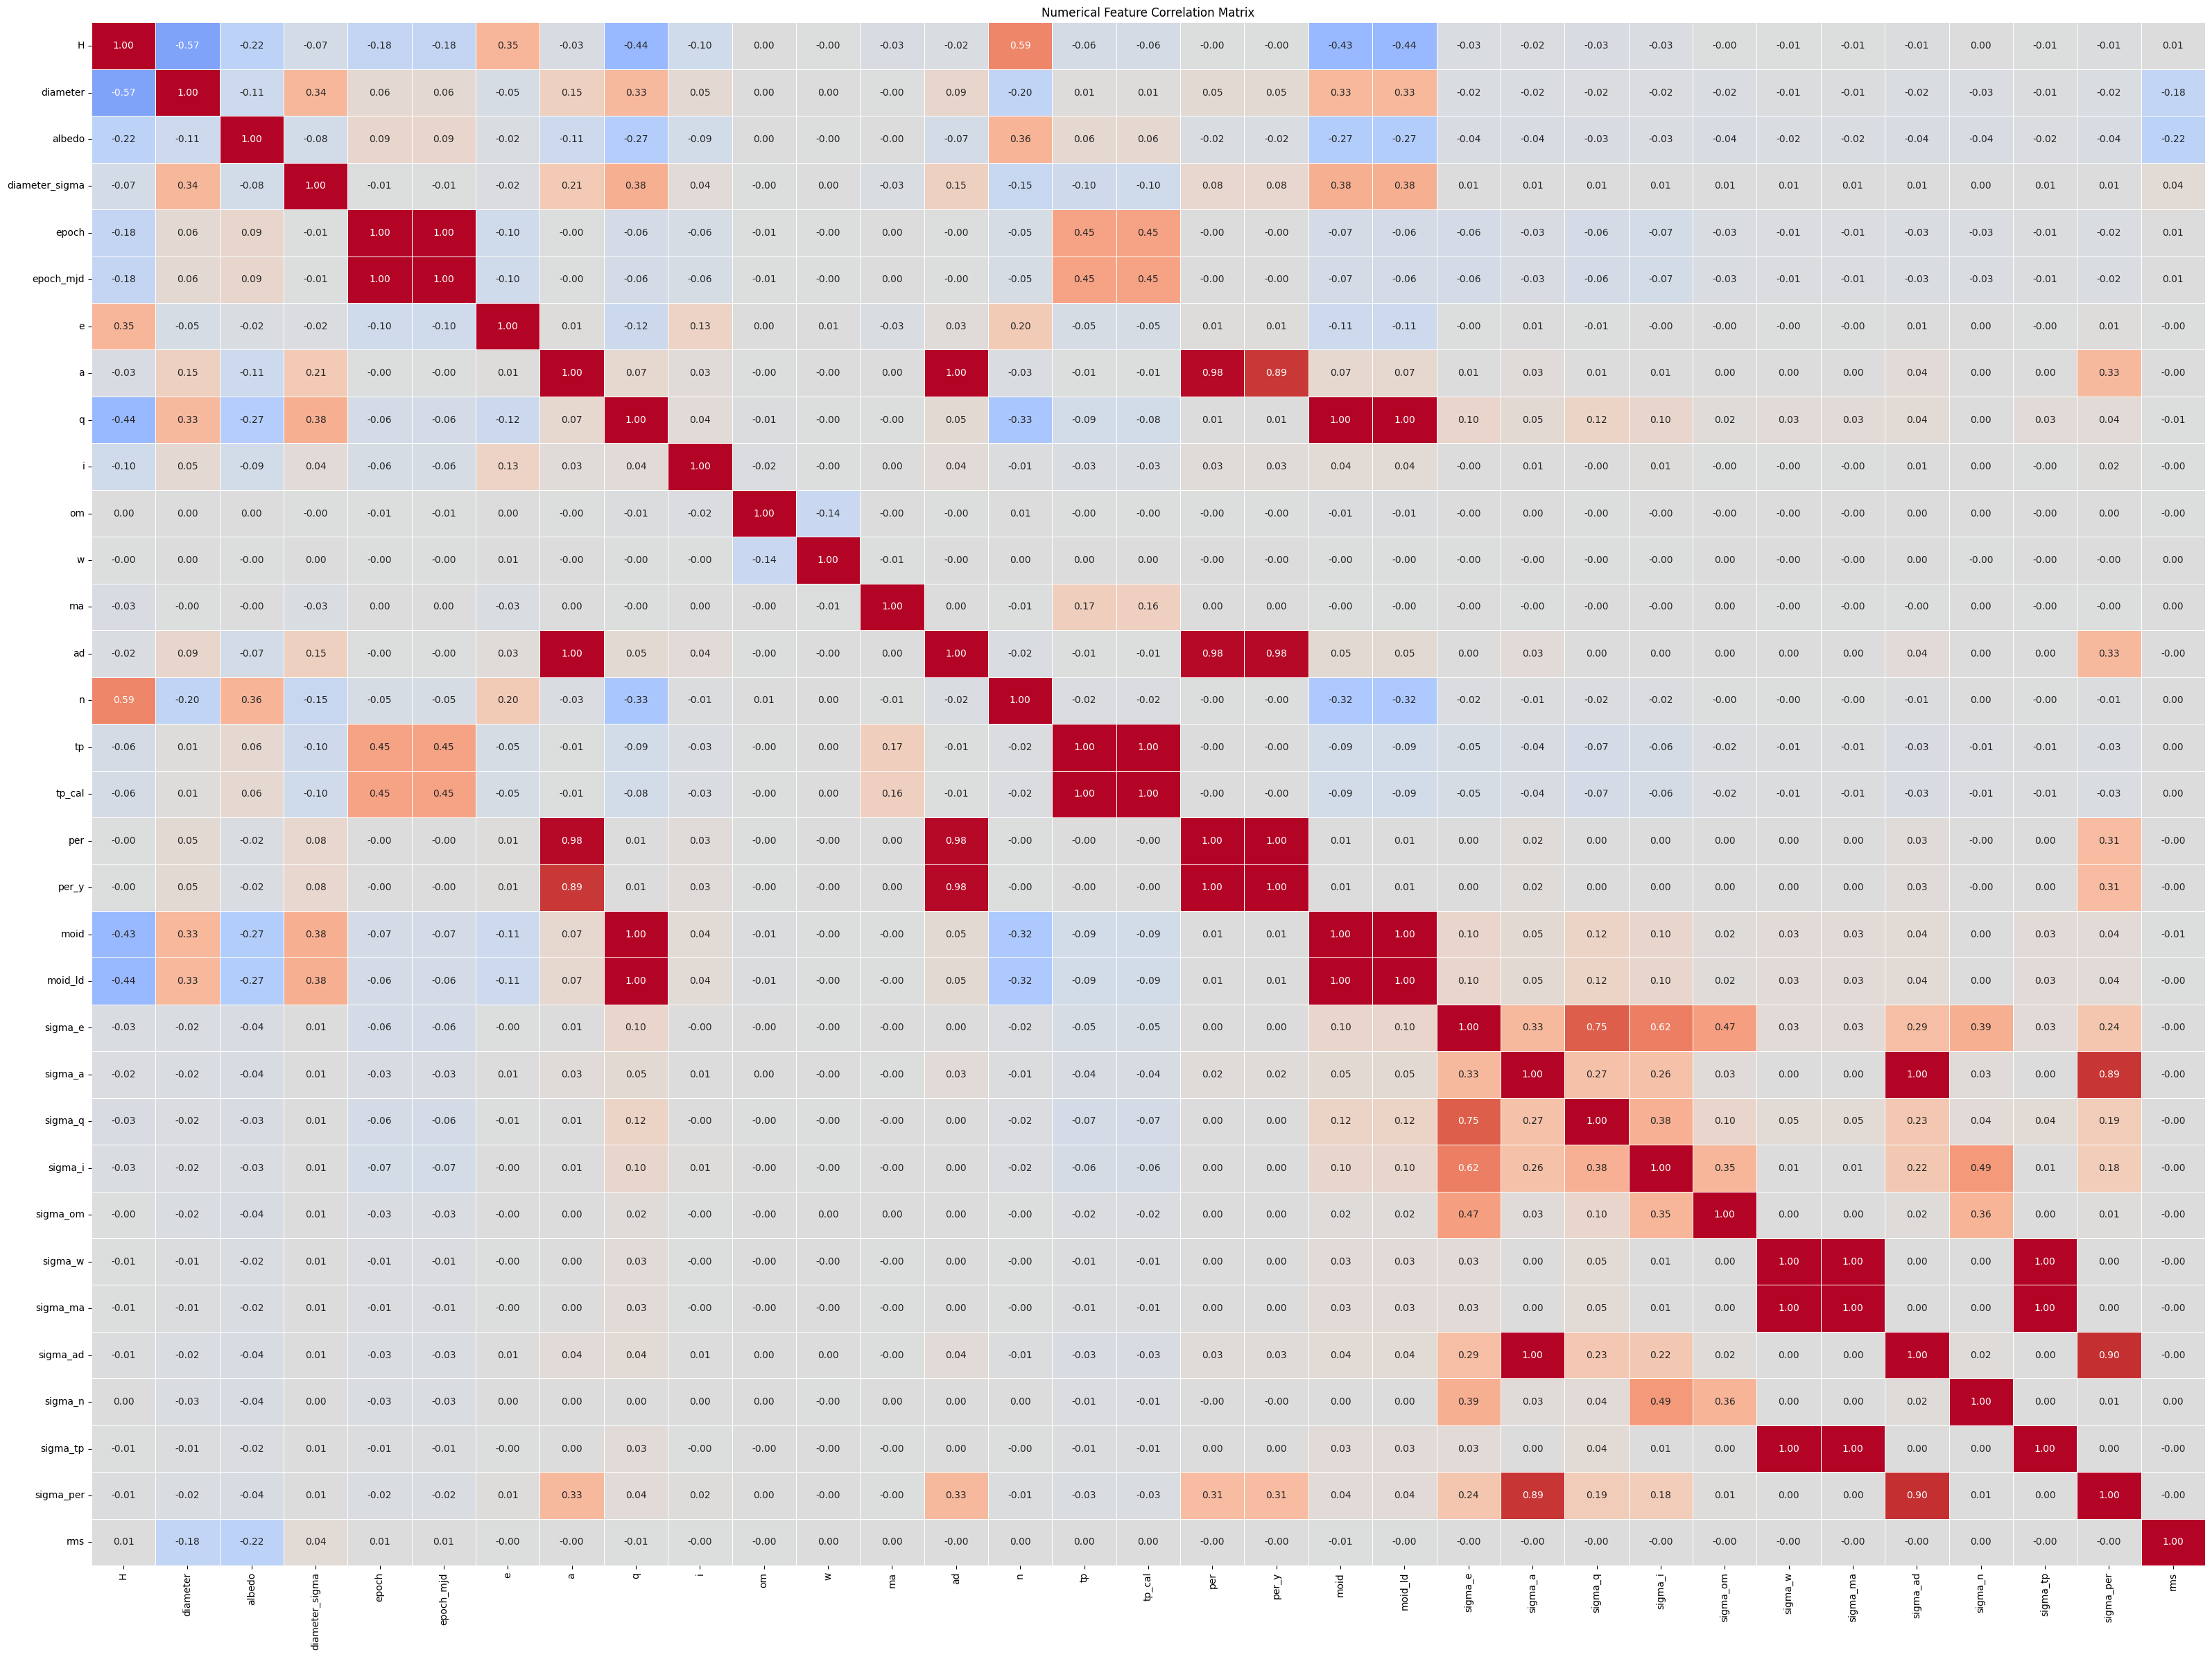

In [142]:
print("CORRELATIONS")

correlation_matrix = df[numeric_cols].corr(
    method="pearson"
)

plt.figure(figsize=(16*2, 12*2))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    annot=True,
    fmt=".2f",
    cbar=False
)

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()
plt.show()

# preprossing

In [143]:
print("\nScientific validity checks:")

validity_checks = {}

# Diameter should not be negative
if "diameter" in df.columns:
    validity_checks["diameter < 0"] = (
        df["diameter"] < 0
    ).sum()

# Albedo normally should be >= 0
if "albedo" in df.columns:
    validity_checks["albedo < 0"] = (
        df["albedo"] < 0
    ).sum()

# Eccentricity should normally be >= 0
if "e" in df.columns:
    validity_checks["e < 0"] = (
        df["e"] < 0
    ).sum()

# Inclination should normally be >= 0
if "i" in df.columns:
    validity_checks["i < 0"] = (
        df["i"] < 0
    ).sum()

# Semi-major axis should normally be positive
if "a" in df.columns:
    validity_checks["a <= 0"] = (
        df["a"] <= 0
    ).sum()

# Perihelion distance should be positive
if "q" in df.columns:
    validity_checks["q <= 0"] = (
        df["q"] <= 0
    ).sum()

display(
    pd.DataFrame(
        validity_checks.items(),
        columns=["Check", "Invalid Count"]
    )
)


Scientific validity checks:


,Check,Invalid Count
0,diameter < 0,0
1,albedo < 0,0
2,e < 0,0
3,i < 0,0
4,a <= 0,4
5,q <= 0,0


# cleaing

In [144]:
df_clean = df.copy()

In [145]:
small_missing_cols = [
   'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q',
    'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad',
    'sigma_n', 'sigma_tp', 'sigma_per', 'rms'
]

# تعويض القيم المفقودة باستخدام الوسيط (Median) لكل عمود
for col in small_missing_cols:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

In [146]:
if 'H' in df_clean.columns:
    # حساب المتوسط لعمود H
    mean_h = df_clean['H'].mean()

    # تعويض القيم المفقودة (NaN) بقيمة المتوسط
    df_clean['H'].fillna(mean_h, inplace=True)

In [147]:
import numpy as np

# عدادات لتسجيل عدد القيم التي تم ايجادها
d_imputed_count = 0
p_imputed_count = 0

# التأكد من وجود الأعمدة الأساسية في الداتا
required_cols = ['diameter', 'albedo', 'H']
if all(col in df_clean.columns for col in required_cols):

    # 1. إذا كان القطر (diameter) مفقوداً والانعكاسية (albedo) موجودة و H موجود
    mask_calc_d = df_clean['diameter'].isnull() & df_clean['albedo'].notnull() & df_clean['H'].notnull()

    if mask_calc_d.sum() > 0:
        # حساب القطر باستخدام المعادلة الفلكية
        calc_d = (1329 / np.sqrt(df_clean.loc[mask_calc_d, 'albedo'])) * (10 ** (-0.2 * df_clean.loc[mask_calc_d, 'H']))
        df_clean.loc[mask_calc_d, 'diameter'] = calc_d
        d_imputed_count = mask_calc_d.sum()

    # 2. إذا كانت الانعكاسية (albedo) مفقودة والقطر (diameter) موجود و H موجود
    mask_calc_p = df_clean['albedo'].isnull() & df_clean['diameter'].notnull() & df_clean['H'].notnull()

    if mask_calc_p.sum() > 0:
        # حساب الانعكاسية بالمعادلة العكسية
        calc_p = ((1329 / df_clean.loc[mask_calc_p, 'diameter']) ** 2) * (10 ** (-0.4 * df_clean.loc[mask_calc_p, 'H']))
        df_clean.loc[mask_calc_p, 'albedo'] = calc_p
        p_imputed_count = mask_calc_p.sum()

    # (الحالة الثالثة: إذا كان الاثنان مفقودين، يتم تخطيهما تلقائياً لعدم تطابق الشروط)

    # طباعة التقرير النهائي بالعدادات
    print("=" * 40)
    print(" تقرير استنتاج القيم الرياضية والفلكية:")
    print("=" * 40)
    print(f"- عدد قيم القطر (diameter) التي تم ايجادها: {d_imputed_count}")
    print(f"- عدد قيم الانعكاسية (albedo) التي تم ايجادها: {p_imputed_count}")
    print(f"- **الإجمالي الكلي للقيم التي تم حسابها:** {d_imputed_count + p_imputed_count}")
    print("=" * 40)

else:
    print("تنبيه: بعض الأعمدة المطلوبة (diameter, albedo, H) غير موجودة في جدول البيانات.")

 تقرير استنتاج القيم الرياضية والفلكية:
- عدد قيم القطر (diameter) التي تم ايجادها: 3
- عدد قيم الانعكاسية (albedo) التي تم ايجادها: 1109
- **الإجمالي الكلي للقيم التي تم حسابها:** 1112


In [148]:
# لمعرفة عدد القيم المفقودة في كل عمود على حدة (مرتبة تنازلياً)
missing_counts = df_clean.isnull().sum().sort_values(ascending=False)
print("عدد القيم المفقودة في كل عمود:")
print(missing_counts)

# لمعرفة إجمالي عدد القيم المفقودة في جدول البيانات بالكامل
total_missing = df_clean.isnull().sum().sum()
print(f"\nإجمالي القيم المفقودة في الداتا بالكامل: {total_missing}")

عدد القيم المفقودة في كل عمود:
diameter_sigma    822443
diameter          822312
albedo            822312
pha                19921
neo                    4
per                    4
ad                     4
per_y                  1
ma                     1
H                      0
e                      0
epoch_mjd              0
epoch                  0
i                      0
q                      0
a                      0
w                      0
om                     0
n                      0
tp                     0
equinox                0
tp_cal                 0
moid                   0
moid_ld                0
sigma_e                0
sigma_a                0
sigma_q                0
sigma_i                0
sigma_om               0
sigma_w                0
sigma_ma               0
sigma_ad               0
sigma_n                0
sigma_tp               0
sigma_per              0
class                  0
rms                    0
dtype: int64

إجمالي القيم المفقودة في الدات

geting dia

In [149]:
df_dia=df_clean.drop(['epoch','equinox',
           'epoch_mjd','i', 'om', 'w','ma','tp', 'tp_cal', 'per', 'per_y','sigma_e', 'sigma_a',
           'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w','sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per'],axis=1)

In [150]:
print(f" Shape after droping unnessesary columns : {df_dia.shape}")

 Shape after droping unnessesary columns : (958524, 15)


In [151]:
df_dia=df_dia.dropna(subset=["diameter"])
print(f"Shape after droping the target nulls :{df_dia.shape}")

Shape after droping the target nulls :(136212, 15)


In [152]:
#null percentage in each column

print("Missing value percentage in each column after dropping the diameter nulls :")
(df_dia.isna().sum()/len(df)*100).sort_values(ascending=False)

Missing value percentage in each column after dropping the diameter nulls :


,0
diameter_sigma,0.013667
pha,0.000000
neo,0.000000
H,0.000000
diameter,0.000000
albedo,0.000000
e,0.000000
a,0.000000
q,0.000000
ad,0.000000


Text(0.5, 0.98, 'Distribution of Features with Missing Values')

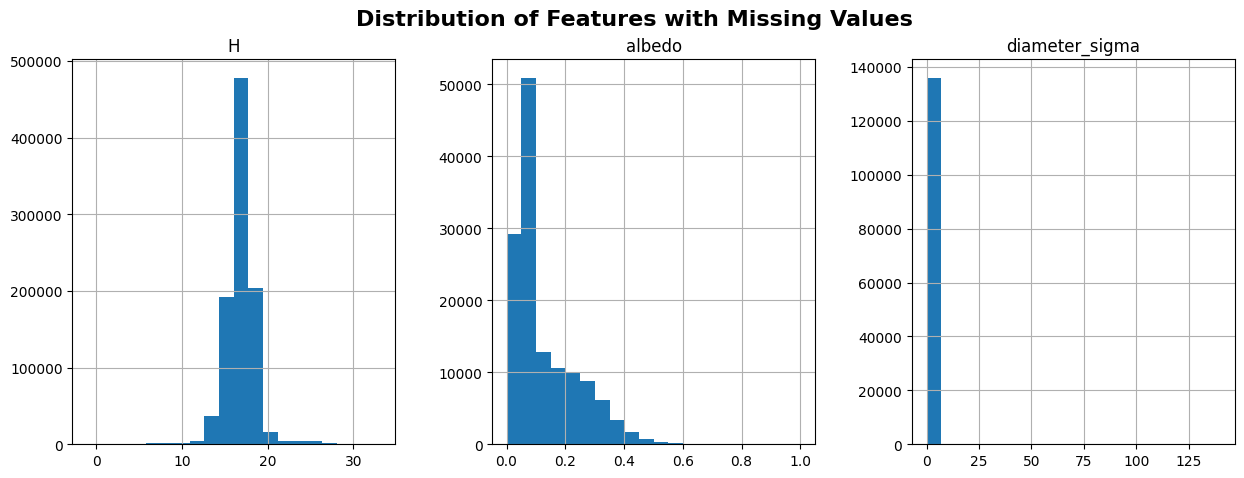

In [153]:
cols=['H','albedo','diameter_sigma']
df[cols].hist(bins=20, figsize=(15, 5), layout=(1,3))
plt.suptitle("Distribution of Features with Missing Values",fontsize=16,fontweight="bold")